In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df_train = pd.read_csv('data_training.csv')
df_test = pd.read_csv('data_testing.csv')

print("Dataset berhasil dimuat!")
df_train.head()

Dataset berhasil dimuat!


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


# Exploratory Data Analysis
Tahap ini dilakukan untuk memahami karakteristik data. Pertama, melihat distribusi skor kualitas anggur untuk mengetahui apakah data seimbang atau tidak.

/tmp/ipykernel_8461/1548206263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df_train, palette='viridis')


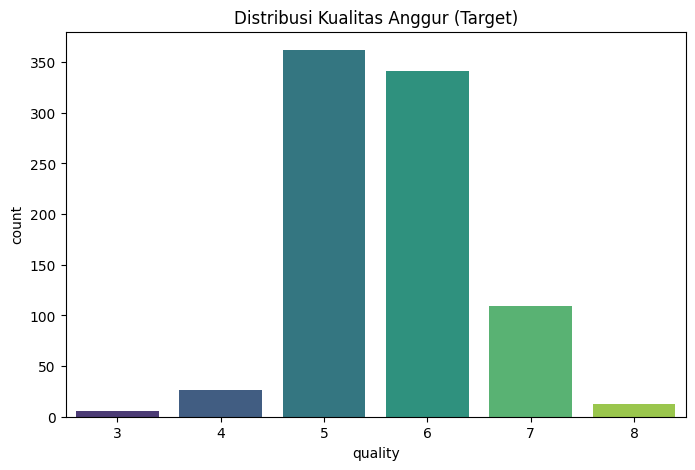

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df_train, palette='viridis')
plt.title('Distribusi Kualitas Anggur (Target)')
plt.show()

# Interpretasi Distribusi
Berdasarkan grafik di atas, terlihat bahwa data didominasi oleh anggur dengan skor kualitas 5 dan 6. Sampel untuk kualitas ekstrem seperti 3 dan 8 sangat sedikit, yang menandakan adanya class imbalance.

# Analisis Korelasi
Selanjutnya, melihat hubungan antar fitur menggunakan matriks korelasi (Heatmap) untuk mengetahui zat kimia mana yang paling memengaruhi kualitas.

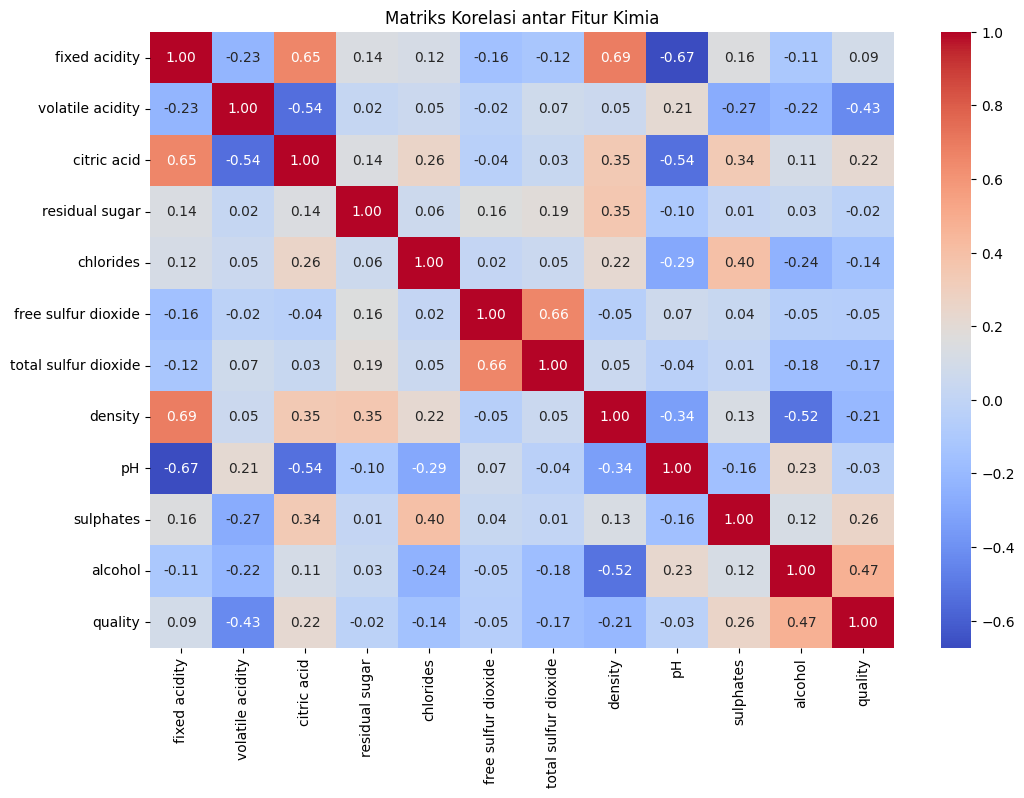

In [15]:
plt.figure(figsize=(12, 8))
correlation = df_train.drop('Id', axis=1).corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi antar Fitur Kimia')
plt.show()

# Interpretasi Korelasi
Fitur Alcohol memiliki korelasi positif tertinggi terhadap kualitas, sedangkan Volatile Acidity memiliki korelasi negatif yang signifikan. Ini berarti semakin tinggi alkohol dan semakin rendah keasaman yang menguap, kualitas anggur cenderung lebih baik.

# Preprocessing Data
Pada tahap ini, menghapus kolom Id karena tidak relevan dengan kualitas. Kemudian, data dibagi menjadi 80% untuk pelatihan (Training Set) dan 20% untuk validasi (Validation Set).

In [16]:
X = df_train.drop(columns=['quality', 'Id'])
y = df_train['quality']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data siap dilatih!")

Data siap dilatih!


# Pemodelan dan Evaluasi
Model yang digunakan adalah Random Forest Classifier. Algoritma ini dipilih karena ketahanannya terhadap outlier dan kemampuannya menangani pola data yang kompleks.

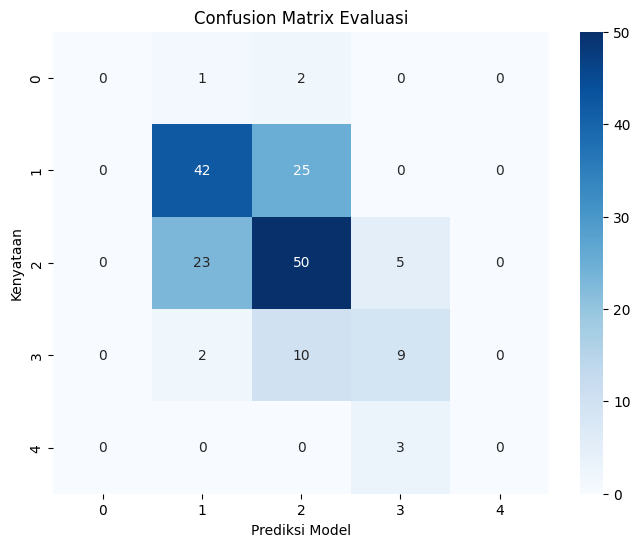

Akurasi: 58.72%


In [17]:
# Membuat dan melatih model
model_wine = RandomForestClassifier(n_estimators=100, random_state=42)
model_wine.fit(X_train, y_train)

# Prediksi data validasi
y_pred = model_wine.predict(X_val)

# Tampilkan Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan')
plt.title('Confusion Matrix Evaluasi')
plt.show()

print(f"Akurasi: {accuracy_score(y_val, y_pred) * 100:.2f}%")

# Interpretasi Model
Model mencapai akurasi sekitar 58.72%. Berdasarkan Confusion Matrix, model sangat kuat dalam menebak kualitas 5 dan 6, namun terkadang masih tertukar karena kemiripan profil kimiawi antar skor kualitas yang berdekatan.

# Fitur Paling Berpengaruh
Kemudian melihat fitur kimia apa yang paling menentukan dalam prediksi kualitas menurut model Random Forest.

/tmp/ipykernel_8461/1041801858.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kepentingan', y='Fitur', data=data_penting, palette='magma')


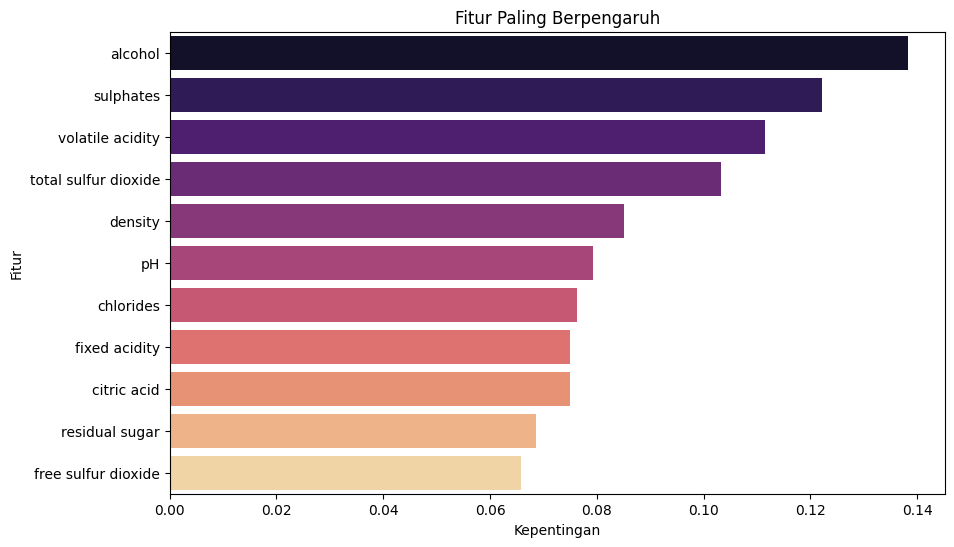

In [18]:
importances = model_wine.feature_importances_
features = X.columns
data_penting = pd.DataFrame({'Fitur': features, 'Kepentingan': importances}).sort_values(by='Kepentingan', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Kepentingan', y='Fitur', data=data_penting, palette='magma')
plt.title('Fitur Paling Berpengaruh')
plt.show()

In [19]:
# Prediksi data testing
X_test_final = df_test.drop(columns=['Id'])
hasil_prediksi = model_wine.predict(X_test_final)

# Buat dataframe hasil
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'quality': hasil_prediksi
})

# Simpan file (Ganti 065 dengan NIM kamu)
submission.to_csv('hasilprediksi_065.csv', index=False)
print("File prediksi berhasil dibuat!")

File prediksi berhasil dibuat!
